In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
downflux = pd.read_csv('output/WASP15b/WASP15b_spec_downflux.dat', sep='\\s+', header=2)

In [3]:
downflux.head()

,bin,cent_lambda[um],low_int_lambda[um],delta_lambda[um],F_down[0],F_down[1],F_down[2],F_down[3],F_down[4],F_down[5],...,F_down[96],F_down[97],F_down[98],F_down[99],F_down[100],F_down[101],F_down[102],F_down[103],F_down[104],F_down[105]
0,0,0.246440,0.244000,0.004880,3.596195e+14,1.997184e+14,1.047407e+14,5.267570e+13,2.533487e+13,1.161930e+13,...,5.399364e+11,5.432959e+11,5.464343e+11,5.494765e+11,5.525186e+11,5.556001e+11,5.587027e+11,5.617673e+11,5.647185e+11,5.725281e+11
1,1,0.251369,0.248880,0.004978,3.912218e+14,2.197878e+14,1.167328e+14,5.950285e+13,2.903197e+13,1.351989e+13,...,4.712999e+11,4.755825e+11,4.794919e+11,4.831033e+11,4.865543e+11,4.900119e+11,4.936150e+11,4.974278e+11,5.014259e+11,5.100075e+11
2,2,0.256396,0.253858,0.005077,4.240791e+14,2.409524e+14,1.295701e+14,6.692437e+13,3.311545e+13,1.565422e+13,...,7.933416e+11,7.944356e+11,7.953413e+11,7.960925e+11,7.967438e+11,7.974100e+11,7.983061e+11,7.997453e+11,8.020613e+11,8.054915e+11
3,3,0.261524,0.258935,0.005179,4.580804e+14,2.631691e+14,1.432474e+14,7.495291e+13,3.760304e+13,1.803854e+13,...,8.236266e+11,8.236938e+11,8.237514e+11,8.238266e+11,8.239880e+11,8.243665e+11,8.251416e+11,8.264888e+11,8.285126e+11,8.312066e+11
4,4,0.266755,0.264113,0.005282,4.931047e+14,2.863823e+14,1.577510e+14,8.359606e+13,4.251000e+13,2.068818e+13,...,1.828962e+12,1.829439e+12,1.830258e+12,1.831508e+12,1.833212e+12,1.835313e+12,1.837698e+12,1.840229e+12,1.842772e+12,1.845218e+12


In [4]:
#get total flux at each pressure level by summing over all wavelength bins
total_downflux = downflux.iloc[:,4:].sum(axis=0)

In [5]:
total_downflux

F_down[0]      6.963456e+16
F_down[1]      5.200191e+16
F_down[2]      3.833461e+16
F_down[3]      2.817437e+16
F_down[4]      2.065983e+16
                   ...     
F_down[101]    3.505706e+14
F_down[102]    3.506833e+14
F_down[103]    3.508045e+14
F_down[104]    3.509473e+14
F_down[105]    3.513107e+14
Length: 106, dtype: float64

In [6]:
tp = pd.read_csv('output/WASP15b/WASP15b_tp.dat', sep='\\s+', header=1)

In [7]:
tp

,layer,temp.[K],press.[10^-6bar],altitude[cm],height.of.layer[cm],"conv.unstable?[1:yes,0:no]","conv.lapse-rate?[1:yes,0:no]",pl.eff.temp.[K]
0,BOA,6255.95,1.000000e+09,-7.342230e+08,not_avail.,0,1,1671.75
1,0,6062.09,8.956800e+08,-6.990860e+08,7.02737e+07,0,1,NaN
2,1,5692.22,7.185540e+08,-6.317060e+08,6.44851e+07,0,1,NaN
3,2,5344.91,5.764550e+08,-5.701280e+08,5.86714e+07,0,1,NaN
4,3,5018.80,4.624570e+08,-5.140760e+08,5.34322e+07,0,1,NaN
...,...,...,...,...,...,...,...,...
101,100,1341.59,2.414210e-01,1.247970e+09,1.25674e+07,0,0,NaN
102,101,1334.44,1.936780e-01,1.260510e+09,1.24993e+07,0,0,NaN
103,102,1330.43,1.553770e-01,1.272990e+09,1.24612e+07,0,0,NaN
104,103,1328.02,1.246500e-01,1.285440e+09,1.24382e+07,0,0,NaN


Text(0.5, 0, 'Total Downward Flux [erg/cm^2/s]')

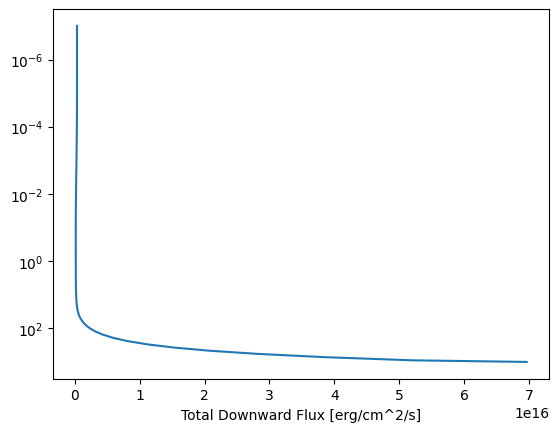

In [8]:
plt.plot(total_downflux.values, tp['press.[10^-6bar]']/1e6)
plt.yscale('log')
plt.gca().invert_yaxis()
plt.xlabel('Total Downward Flux [erg/cm^2/s]')

In [9]:
upflux = pd.read_csv('output/WASP15b/WASP15b_spec_upflux.dat', sep='\\s+', header=2)

In [10]:
total_upflux = upflux.iloc[:,4:].sum(axis=0)

Text(0.5, 0, 'Total Upward Flux [erg/cm^2/s]')

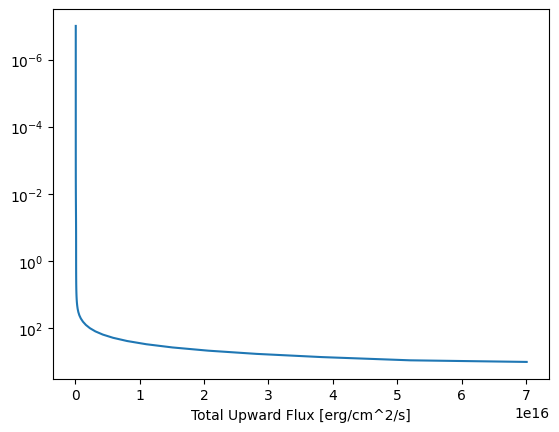

In [11]:
plt.plot(total_upflux.values, tp['press.[10^-6bar]']/1e6)
plt.yscale('log')
plt.gca().invert_yaxis()
plt.xlabel('Total Upward Flux [erg/cm^2/s]')

In [26]:
net_flux = total_upflux.values - total_downflux.values
net_flux_band = net_flux[1:] - net_flux[:-1]

Text(0.5, 0, 'Total Upward Flux [erg/cm^2/s]')

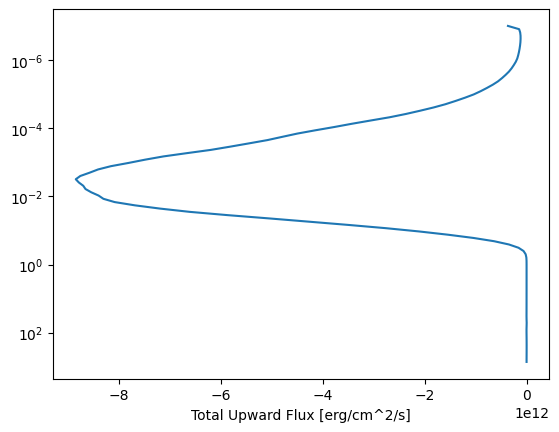

In [29]:
plt.plot(net_flux_band[1:], tp['press.[10^-6bar]'][2:]/1e6)
plt.yscale('log')
plt.gca().invert_yaxis()
plt.xlabel('Total Upward Flux [erg/cm^2/s]')

In [25]:
len(net_flux)

106

In [18]:
#get net flux per band
# keep the same first three columns as downflux, then add net flux columns (F_up - F_down)
net_flux_per_interface = downflux.iloc[:, :4].copy()

flux_up = upflux.iloc[:, 4:]
flux_down = downflux.iloc[:, 4:]

# compute net values and name columns F_net[...]
net_vals = flux_up.values - flux_down.values
net_cols = [c.replace('F_up', 'F_net') for c in flux_up.columns]

net_flux_df = pd.DataFrame(net_vals, columns=net_cols, index=downflux.index)

# combine
net_flux_per_interface = pd.concat([net_flux_per_interface.reset_index(drop=True), net_flux_df.reset_index(drop=True)], axis=1)

In [20]:
net_flux_per_interface

,bin,cent_lambda[um],low_int_lambda[um],delta_lambda[um],F_net[0],F_net[1],F_net[2],F_net[3],F_net[4],F_net[5],...,F_net[96],F_net[97],F_net[98],F_net[99],F_net[100],F_net[101],F_net[102],F_net[103],F_net[104],F_net[105]
0,0,0.246440,0.244000,0.004880,4.820363e+12,427000000.0,312000000.0,224900000.0,160200000.0,111800000.0,...,-5.397762e+11,-5.431357e+11,-5.462741e+11,-5.493163e+11,-5.523583e+11,-5.554398e+11,-5.585425e+11,-5.616071e+11,-5.645583e+11,-5.723679e+11
1,1,0.251369,0.248880,0.004978,5.142308e+12,193000000.0,140000000.0,99000000.0,68500000.0,45500000.0,...,-4.712769e+11,-4.755595e+11,-4.794689e+11,-4.830803e+11,-4.865313e+11,-4.899888e+11,-4.935919e+11,-4.974048e+11,-5.014029e+11,-5.099845e+11
2,2,0.256396,0.253858,0.005077,5.463716e+12,363000000.0,290000000.0,234700000.0,194800000.0,162400000.0,...,-7.926470e+11,-7.937411e+11,-7.946468e+11,-7.953980e+11,-7.960493e+11,-7.967154e+11,-7.976116e+11,-7.990508e+11,-8.013668e+11,-8.047970e+11
3,3,0.261524,0.258935,0.005179,5.786195e+12,269000000.0,217000000.0,177100000.0,149300000.0,127100000.0,...,-8.221649e+11,-8.222321e+11,-8.222898e+11,-8.223649e+11,-8.225263e+11,-8.229048e+11,-8.236799e+11,-8.250271e+11,-8.270509e+11,-8.297449e+11
4,4,0.266755,0.264113,0.005282,6.106612e+12,134000000.0,106000000.0,84300000.0,69400000.0,57900000.0,...,-1.825189e+12,-1.825666e+12,-1.826485e+12,-1.827735e+12,-1.829438e+12,-1.831539e+12,-1.833925e+12,-1.836456e+12,-1.838999e+12,-1.841445e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,380,456.852988,452.329691,9.046594,1.419060e+01,0.0,0.0,0.0,0.0,0.0,...,9.392216e+03,9.392433e+03,9.392605e+03,9.392742e+03,9.392851e+03,9.392938e+03,9.393007e+03,9.393062e+03,9.393107e+03,9.393143e+03
381,381,465.990048,461.376285,9.227526,1.272490e+01,0.0,0.0,0.0,0.0,0.0,...,8.634237e+03,8.634420e+03,8.634563e+03,8.634675e+03,8.634763e+03,8.634833e+03,8.634888e+03,8.634931e+03,8.634966e+03,8.634995e+03
382,382,475.309849,470.603811,9.412076,1.145460e+01,0.0,0.0,0.0,0.0,0.0,...,7.798762e+03,7.800052e+03,7.803207e+03,7.809634e+03,7.820463e+03,7.836093e+03,7.855972e+03,7.879173e+03,7.906266e+03,7.991808e+03
383,383,484.816046,480.015887,9.600318,1.028410e+01,0.0,0.0,0.0,0.0,0.0,...,7.409993e+03,7.410035e+03,7.410067e+03,7.410092e+03,7.410111e+03,7.410126e+03,7.410137e+03,7.410146e+03,7.410154e+03,7.410160e+03


In [ ]:
# find the F_net columns (keep their order)
net_cols = [c for c in net_flux_per_interface.columns if str(c).startswith('F_net')]
net_array = net_flux_per_interface[net_cols].values  # shape (n_bins, n_interfaces)

# difference between adjacent interfaces -> heating per layer (n_interfaces-1 layers)
band_heating = net_array[:, :-1] - net_array[:, 1:]  # shape (n_bins, n_layers)

# build sensible column names for the layers between interfaces
n_layers = band_heating.shape[1]
if 'tp' in globals() and 'layer' in tp.columns and len(tp) == net_array.shape[1]:
    # tp rows correspond to interfaces; layers between interfaces are tp['layer'][1:]
    layer_labels = tp['layer'].astype(str).iloc[1:].tolist()
    band_cols = [f'F_net_layer[{lbl}]' for lbl in layer_labels]
else:
    band_cols = [f'F_net_layer[{i}]' for i in range(n_layers)]

# assemble net_flux_per_band: keep the first four descriptive columns and add band heating columns
net_flux_per_band = pd.concat(
    [net_flux_per_interface.iloc[:, :4].reset_index(drop=True),
     pd.DataFrame(band_heating, columns=band_cols)],
    axis=1
)

# quick sanity info
print("net_flux_per_interface shape:", net_flux_per_interface.shape)
print("net_flux_per_band shape:", net_flux_per_band.shape)
# net_flux_per_band now has one row per spectral bin and one column per atmospheric layer (between interfaces)

net_flux_per_interface shape: (385, 110)
net_flux_per_band shape: (385, 109)


In [22]:
net_flux_per_band

,bin,cent_lambda[um],low_int_lambda[um],delta_lambda[um],F_net_layer[0],F_net_layer[1],F_net_layer[2],F_net_layer[3],F_net_layer[4],F_net_layer[5],...,F_net_layer[95],F_net_layer[96],F_net_layer[97],F_net_layer[98],F_net_layer[99],F_net_layer[100],F_net_layer[101],F_net_layer[102],F_net_layer[103],F_net_layer[104]
0,0,0.246440,0.244000,0.004880,4.819936e+12,115000000.0,87100000.0,64700000.0,48400000.0,36620000.0,...,3.694741e+09,3.359493e+09,3.138338e+09,3.042284e+09,3.041993e+09,3.081501e+09,3.102631e+09,3.064619e+09,2.951200e+09,7.809574e+09
1,1,0.251369,0.248880,0.004978,5.142115e+12,53000000.0,41000000.0,30500000.0,23000000.0,16820000.0,...,4.673891e+09,4.282595e+09,3.909378e+09,3.611372e+09,3.451007e+09,3.457568e+09,3.603109e+09,3.812816e+09,3.998107e+09,8.581627e+09
2,2,0.256396,0.253858,0.005077,5.463353e+12,73000000.0,55300000.0,39900000.0,32400000.0,28820000.0,...,1.312478e+09,1.094081e+09,9.056922e+08,7.511356e+08,6.513215e+08,6.661608e+08,8.961433e+08,1.439210e+09,2.315993e+09,3.430187e+09
3,3,0.261524,0.258935,0.005179,5.785926e+12,52000000.0,39900000.0,27800000.0,22200000.0,19480000.0,...,8.690472e+07,6.720586e+07,5.766782e+07,7.513912e+07,1.613955e+08,3.784828e+08,7.751695e+08,1.347211e+09,2.023798e+09,2.693920e+09
4,4,0.266755,0.264113,0.005282,6.106478e+12,28000000.0,21700000.0,14900000.0,11500000.0,9140000.0,...,2.625034e+08,4.771597e+08,8.182150e+08,1.250349e+09,1.703513e+09,2.100926e+09,2.385289e+09,2.531321e+09,2.543313e+09,2.445264e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,380,456.852988,452.329691,9.046594,1.419060e+01,0.0,0.0,0.0,0.0,0.0,...,-2.724273e-01,-2.167854e-01,-1.724306e-01,-1.371280e-01,-1.090469e-01,-8.675603e-02,-6.909704e-02,-5.520831e-02,-4.425946e-02,-3.597450e-02
381,381,465.990048,461.376285,9.227526,1.272490e+01,0.0,0.0,0.0,0.0,0.0,...,-2.324046e-01,-1.823525e-01,-1.431063e-01,-1.122980e-01,-8.819284e-02,-6.943039e-02,-5.482476e-02,-4.356555e-02,-3.489826e-02,-2.878270e-02
382,382,475.309849,470.603811,9.412076,1.145460e+01,0.0,0.0,0.0,0.0,0.0,...,-4.939520e-01,-1.290450e+00,-3.154622e+00,-6.426948e+00,-1.082897e+01,-1.563065e+01,-1.987843e+01,-2.320171e+01,-2.709257e+01,-8.554221e+01
383,383,484.816046,480.015887,9.600318,1.028410e+01,0.0,0.0,0.0,0.0,0.0,...,-5.440070e-02,-4.186569e-02,-3.221476e-02,-2.479071e-02,-1.909848e-02,-1.476600e-02,-1.150119e-02,-9.057230e-03,-7.241245e-03,-6.124732e-03


In [23]:
net_flux_per_band.sum(axis=0)

bin                   7.392000e+04
cent_lambda[um]       2.520781e+04
low_int_lambda[um]    2.495823e+04
delta_lambda[um]      4.991645e+02
F_net_layer[0]        4.733563e+14
                          ...     
F_net_layer[100]      1.174545e+11
F_net_layer[101]      1.181128e+11
F_net_layer[102]      1.255870e+11
F_net_layer[103]      1.462055e+11
F_net_layer[104]      3.654449e+11
Length: 109, dtype: float64

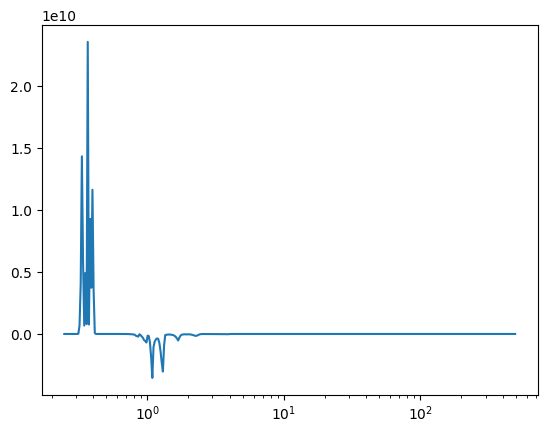

In [38]:
plt.plot(net_flux_per_band['cent_lambda[um]'],net_flux_per_band['F_net_layer[35]'])
plt.xscale('log')